<a href="https://colab.research.google.com/github/valceven/AliacSearchAlgo/blob/master/ISCapstoneInception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#get data from roboflow

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="c32eqh0UKXsSvs8U2Iga")
project = rf.workspace("haqqi").project("chicken-disease-avk9p")
version = project.version(1)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chicken-Disease-1 in folder:: 100%|██████████| 7726/7726 [00:00<00:00, 9550.31it/s]


In [4]:
import os

os.listdir('Chicken-Disease-1/train')

['Salmonella', 'NewCastleDisease', 'Coccidiosis', 'Healthy']

In [45]:
import os
from pathlib import Path

path = 'Chicken-Disease-1'

def count_images_in_folder(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        total += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return total

cocci_count = count_images_in_folder(os.path.join(path, "Coccidiosis"))
salmo_count = count_images_in_folder(os.path.join(path, "Salmonella"))
healthy_count = count_images_in_folder(os.path.join(path, "Healthy"))
newcastle_count = count_images_in_folder(os.path.join(path, "NewCastleDisease"))

print(f"Cocci Images: {cocci_count}")
print(f"Salmo Images: {salmo_count}")
print(f"Healthy Images: {healthy_count}")
print(f"Newcastle Images: {newcastle_count}")

Cocci Images: 0
Salmo Images: 0
Healthy Images: 0
Newcastle Images: 0


In [46]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

IMG_SIZE = (224, 224, 3)
BATCH_SIZE = 32

def preprocess_image(img, label):
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, label

In [50]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # Ensures reproducibility

# Train and validation from 'train' using split
train_ds = image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.43,
    subset="training",
    seed=SEED,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = image_dataset_from_directory(
    os.path.join(path, "train"),
    validation_split=0.43,
    subset="validation",
    seed=SEED,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = image_dataset_from_directory(
    os.path.join(path, "test"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# Access the class names before applying map
class_names = train_ds.class_names
print("Classes:", class_names)

# # Now apply the preprocessing function
# train_ds = train_ds.map(preprocess_image)
# val_ds = val_ds.map(preprocess_image)
# test_ds = test_ds.map(preprocess_image)

# Optional: Confirm batch sizes
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 5406 files belonging to 4 classes.
Using 3082 files for training.
Found 5406 files belonging to 4 classes.
Using 2324 files for validation.
Found 2308 files belonging to 4 classes.
Classes: ['Coccidiosis', 'Healthy', 'NewCastleDisease', 'Salmonella']
Train batches: 97
Val batches: 73
Test batches: 73


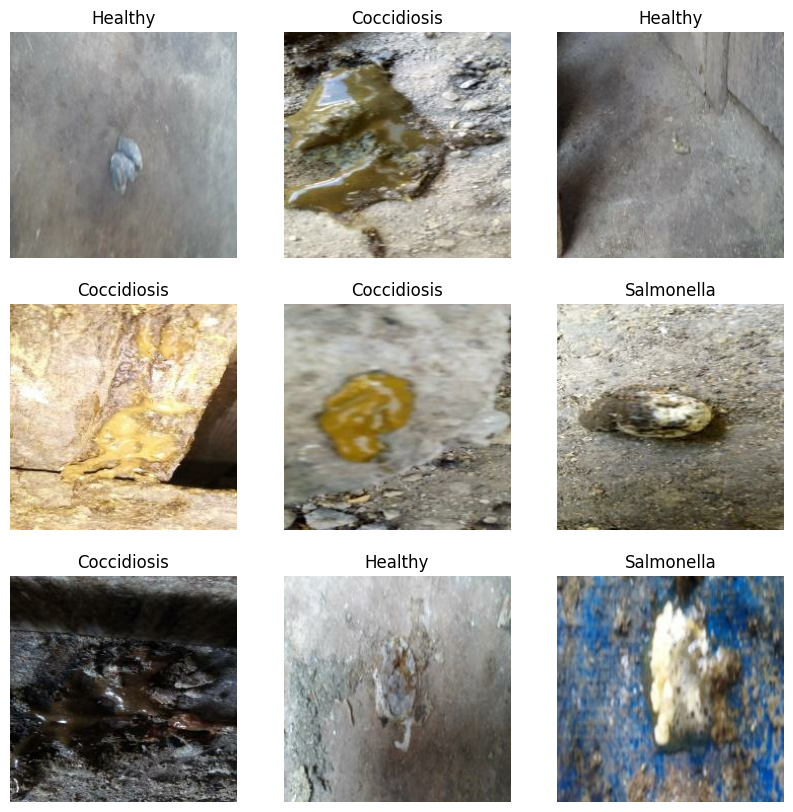

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch from your training dataset

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert to uint8 if needed
        label_index = np.argmax(labels[i])  # Get the index of the highest score
        plt.title(class_names[label_index])
        plt.axis("off")

In [62]:

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base_model = InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,075,524 (84.21 MB)

 Trainable params: 272,740 (1.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [63]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[EarlyStopping(patience=3)]
)

Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 258ms/step - accuracy: 0.3102 - loss: 9.2828 - val_accuracy: 0.4165 - val_loss: 1.3104
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.3467 - loss: 1.3290 - val_accuracy: 0.4505 - val_loss: 1.2395
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.3621 - loss: 1.2824 - val_accuracy: 0.3576 - val_loss: 1.2784
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.3482 - loss: 1.2551 - val_accuracy: 0.3980 - val_loss: 1.2469
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.3850 - loss: 1.2417 - val_accuracy: 0.5082 - val_loss: 1.1354
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.3813 - loss: 1.2380 - val_accuracy: 0.4862 - val_loss: 1.1647
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.3717 - loss: 1.2306 - val_accuracy: 0.4359 - val_loss: 1.2194
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.3828 - loss: 1.2315 - val_accu

In [ ]:
base_model.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds,
          validation_data=val_ds,
          epochs=50,
          callbacks=[EarlyStopping(patience=5)]
          )

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 158s 771ms/step - accuracy: 0.3461 - loss: 1.2699 - val_accuracy: 0.5039 - val_loss: 1.2426
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 68s 298ms/step - accuracy: 0.4447 - loss: 1.2291 - val_accuracy: 0.5977 - val_loss: 1.1821
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 293ms/step - accuracy: 0.4443 - loss: 1.1917 - val_accuracy: 0.6308 - val_loss: 1.1120
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step - accuracy: 0.5312 - loss: 1.1303 - val_accuracy: 0.6446 - val_loss: 1.0660
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.5543 - loss: 1.1023 - val_accuracy: 0.6463 - val_loss: 1.0339
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.5789 - loss: 1.0424 - val_accuracy: 0.6829 - val_loss: 1.0120
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 294ms/step - accuracy: 0.6033 - loss: 1.0186 - val_accuracy: 0.7418 - val_loss: 0.9807
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.6214 - loss: 0.9844 - val_acc

In [1]:
model.evaluate(test_ds)

NameError: name 'model' is not defined

In [ ]:
model.save('capstone1inception.h5')
from google.colab import files
files.download("capstone1inception.h5")

In [ ]:
# from google.colab import files

# uploaded = files.upload()
# !unzip model_folder.zip -d model_folder

Saving preprocessed_image21.h5 to preprocessed_image21.h5
unzip:  cannot find or open model_folder.zip, model_folder.zip.zip or model_folder.zip.ZIP.


In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model("preprocessed_image21.h5")

In [ ]:
import numpy as np

preds = model.predict(test_ds)
y_pred = np.argmax(preds, axis=1)  # Convert from one-hot to class indices

y_true = []
for _, label in test_ds.unbatch():
    y_true.append(np.argmax(label.numpy()))  # Convert one-hot to index
y_true = np.array(y_true)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)  # Replace with your class names
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

print("Predicted:", y_pred[:10])
print("True     :", y_true[:10])
# Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Manual accuracy: {accuracy:.2%}")
